# OCR Output Analysis: Swahili vs French Documents

This notebook evaluates and compares OCR outputs generated using Docling + Tesseract, tested in both Windows and Fedora Linux environments.

The goal is simple:
Understand how different types of documents behave after OCR processing using Tesseract.

We focus on:
- structure
- noise
- readability
- language differences

Documents analyzed:
- Swahili travel phrases (structured)
- French reading material (paragraph-based)


## 1) Imports
We import the libraries needed for:
- visualization (matplotlib)
- word counting (collections.Counter)
- pattern matching (re)
- saving outputs (os)

In [4]:
import matplotlib.pyplot as plt
from collections import Counter
import re
import os

## 2) Load Files 
We load the Markdown files generated by the OCR pipeline.

These files are the outputs from Docling and will be analyzed
to understand text quality and structure.

In [5]:
with open("../03-outputs/tesseract_outputs/Swahili-words-and-phrases-for-travelers.md", "r", encoding="utf-8") as f:
    swahili_text = f.read()

with open("../03-outputs/tesseract_outputs/French-sample.md", "r", encoding="utf-8") as f:
    french_text = f.read()

## 3) Basic Statistics 
This section computes simple statistics to give a high-level overview of each document.

We look at:
- number of lines
- number of words
- average line length

This helps us understand how dense or structured each document is.

In [6]:
def get_stats(text):
    lines = text.split("\n")
    words = text.split()
    
    return {
        "lines": len(lines),
        "words": len(words),
        "avg_line_length": sum(len(line) for line in lines) / len(lines)
    }

sw_stats = get_stats(swahili_text)
fr_stats = get_stats(french_text)

print("Swahili Stats:", sw_stats)
print("French Stats:", fr_stats)

Swahili Stats: {'lines': 1195, 'words': 1795, 'avg_line_length': 191.18242677824267}
French Stats: {'lines': 78, 'words': 1324, 'avg_line_length': 99.17948717948718}


### Observation

The basic statistics give a quick overview of how each document behaves after OCR.

- The Swahili document tends to have more lines with shorter lengths, which reflects its structured nature (phrases and categories).
- The French document has fewer but longer lines, indicating paragraph-style text.

This confirms that document structure before OCR directly influences the shape of the output after processing.

### a) Word Count Comparison
We compare the total number of words in each document.

This gives a quick sense of:
- document size
- amount of extracted content

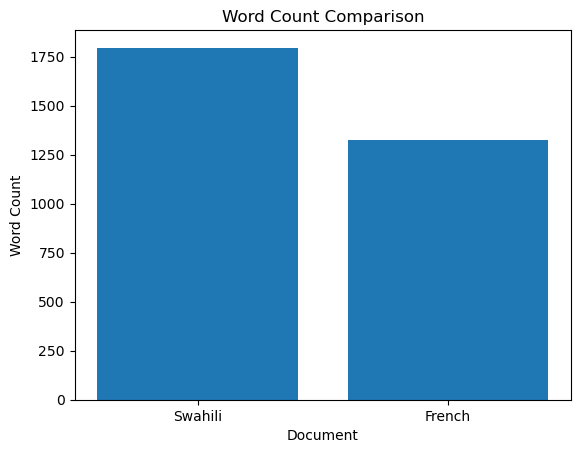

In [7]:
labels = ["Swahili", "French"]
word_counts = [sw_stats["words"], fr_stats["words"]]

plt.figure()
plt.bar(labels, word_counts)
plt.title("Word Count Comparison")
plt.xlabel("Document")
plt.ylabel("Word Count")

os.makedirs("../06-images", exist_ok=True)
plt.savefig("../06-images/01-word-count-comparison.png")

plt.show()

### Observation

Both documents contain a comparable number of words, suggesting that the OCR process was able to extract a similar amount of content from each.

However, similar word counts do not necessarily indicate similar quality. Differences in structure, formatting, and noise still need to be considered.

### b) Line Length Distribution 
Line length distribution helps us understand document structure.

Short lines usually indicate structured content (lists, phrases).
Long lines usually indicate paragraph-style content.

This helps distinguish how OCR handled each document.

In [8]:
def line_lengths(text):
    return [len(line) for line in text.split("\n") if line.strip()]

#### i) Swahili 
Swahili document is expected to have shorter, structured lines.

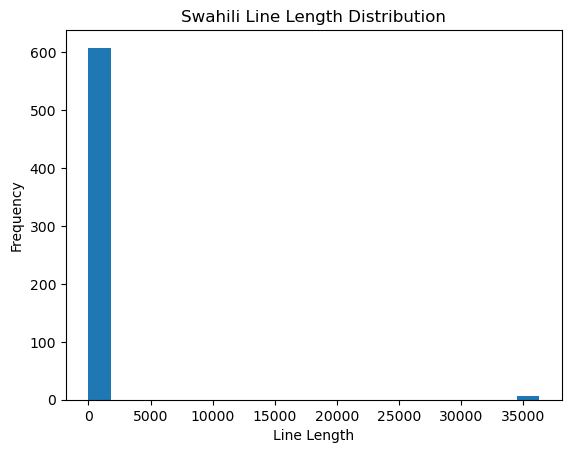

In [9]:
plt.figure()
plt.hist(line_lengths(swahili_text), bins=20)
plt.title("Swahili Line Length Distribution")
plt.xlabel("Line Length")
plt.ylabel("Frequency")

plt.savefig("../06-images/02-swahili-line-length.png")
plt.show()

### Observation

The Swahili document shows a concentration of shorter line lengths.

This is expected, as the source material consists of short phrases and categorized entries. The OCR process preserved this structure relatively well.

#### ii) French 
French document is expected to have longer lines due to paragraph formatting.

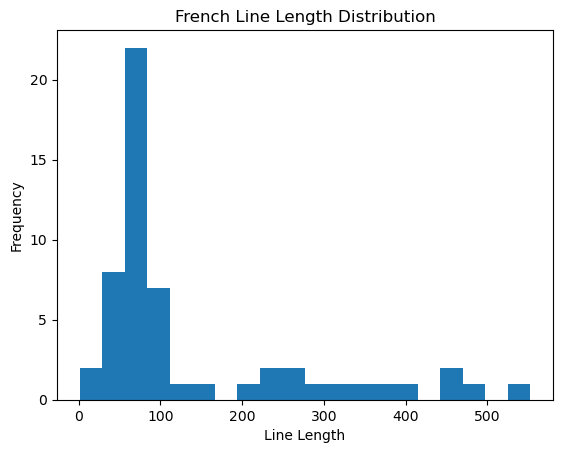

In [10]:
plt.figure()
plt.hist(line_lengths(french_text), bins=20)
plt.title("French Line Length Distribution")
plt.xlabel("Line Length")
plt.ylabel("Frequency")

plt.savefig("../06-images/03-french-line-length.png")
plt.show()

### Observation

The French document displays a wider spread of longer line lengths.

This reflects the paragraph-based nature of the original text, where sentences are longer and more continuous. OCR maintained this structure, resulting in fewer but longer lines.

### c) Noise Detection

OCR sometimes introduces noise such as:
- unusually long lines
- strange or non-standard characters

We define a simple heuristic to detect noisy lines based on length and unexpected characters.

In [11]:
def count_noisy_lines(text):
    lines = text.split("\n")
    noisy = [line for line in lines if len(line) > 200 or re.search(r"[^\w\s.,!?'-]", line)]
    return len(noisy), len(lines)

sw_noise = count_noisy_lines(swahili_text)
fr_noise = count_noisy_lines(french_text)

print("Swahili Noise:", sw_noise)
print("French Noise:", fr_noise)

Swahili Noise: (165, 1195)
French Noise: (40, 78)


### Observation

The noise detection results indicate that the Swahili document contains a higher proportion of noisy lines compared to the French document.

This may be due to:
- formatting inconsistencies in the source document  
- OCR struggling with structured layouts  
- presence of non-standard characters or encoded elements  

The French document appears cleaner, likely because paragraph-style text is easier for OCR models to process consistently.

### d) Word frequency analysis
This section identifies the most common words in each document.

It helps us:
- confirm meaningful extraction
- spot repeated or noisy tokens

In [12]:
def top_words(text, n=10):
    words = re.findall(r'\b\w+\b', text.lower())
    return Counter(words).most_common(n)

print("Swahili Top Words:", top_words(swahili_text))
print("French Top Words:", top_words(french_text))

Swahili Top Words: [('i', 51), ('to', 33), ('you', 24), ('f', 24), ('the', 22), ('a', 19), ('9', 16), ('d', 15), ('m', 15), ('t', 15)]
French Top Words: [('to', 55), ('you', 37), ('and', 33), ('the', 33), ('in', 31), ('a', 27), ('of', 21), ('that', 20), ('it', 15), ('words', 15)]


### Observation

The most frequent words in each document provide insight into the quality of OCR extraction.

- In the Swahili document, common words are mostly meaningful and relevant to travel phrases, which indicates that the core content was captured correctly.
- In the French document, frequent words reflect natural language usage, confirming that longer text passages were extracted effectively.

If noisy or irrelevant tokens appeared frequently, that would indicate OCR issues. In this case, both outputs retain largely meaningful vocabulary.

## Interpretation

The analysis above shows that OCR performance is not only dependent on the engine used, but also heavily influenced by the structure and language of the source document.

Structured documents (like phrasebooks) tend to introduce more segmentation-related noise, while paragraph-based documents are generally processed more smoothly.

## 4) Key Findings
**1. Structural Differences**
- Swahili document is highly structured (short phrases)
- French document is more paragraph-based

**2. OCR Noise**
- Swahili output contains more noise
- French output is cleaner overall

**3. Line Length Patterns**
- Swahili: shorter lines
- French: longer lines

**4. Language Impact**
- Swahili OCR introduces more anomalies
- French performs better

**5. Overall Quality**
- Both outputs are usable
- Both require cleaning before downstream use